# creating dataframe

In [3]:
import os
import pandas as pd
folder_path="E:\data\gameofthrones"

data=[]

for filename in os.listdir(folder_path):
    if filename.endswith('.txt'):
        file_path=os.path.join(folder_path,filename)

        with open(file_path,'r',encoding='latin1') as f:
            text=f.read()

            data.append({
                'filename':filename,
                'text':text
            })
df=pd.DataFrame(data)

In [4]:
df.head()

,filename,text
0,001ssb.txt,A Game Of Thrones \nBook One of A Song of Ice ...
1,002ssb.txt,A Clash of Kings \nBook Two of A song of Ice a...
2,003ssb.txt,A Storm Of Swords \nBook Three of A Song of Ic...
3,004ssb.txt,Version History: \n2.0 - Reedited 4/25/10 by m...
4,005ssb.txt,\n\nGeorge R. R. Martin \nA DANCE WITH DRAGONS...


In [12]:
df['text'][0][0]

'A'

In [6]:
len(df['text'][0])

1607894

In [7]:
df.shape

(5, 2)

In [8]:
import numpy as np
import pandas as pd

In [9]:
# !pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   -- ------------------------------------- 1.3/24.4 MB 8.1 MB/s eta 0:00:03
   --- ------------------------------------ 2.1/24.4 MB 5.5 MB/s eta 0:00:05
   ------ --------------------------------- 4.2/24.4 MB 6.4 MB/s eta 0:00:04
   -------- ------------------------------- 5.2/24.4 MB 5.9 MB/s eta 0:00:04
   ----------- ---------------------------- 6.8/24.4 MB 6.3 MB/s eta 0:00:03
   -------------- ------------------------- 8.7/24.4 MB 6.7 MB/s eta 0:00:03
   ----------------- ---------------------- 10.5/24.4 MB 6.7 MB/s eta 0:00:03
   ------------------ --------------------- 11.5/24.4 MB 6.5 MB/s eta 0:00:02
   --------------------- ------------------ 13.4/24.4 MB 6.7 MB/s eta 0:00:02
   -------------------------- ------------- 16.0/24.4 MB 7.2 MB/s eta 0:00:02
   ------------------------------ --------- 18.4/24.4 MB 7.5 MB/s eta 0:00:01
   --------------------------------- ------ 20.2/24.4 MB 7.6 MB/s eta 0:00:01


In [11]:
import gensim
import os

In [14]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

story=[]

for filename in os.listdir('E:\data\gameofthrones'):
    f=open(os.path.join('E:\data\gameofthrones',filename))
    corpus=f.read()
    raw_sent=sent_tokenize(corpus)

    for sent in raw_sent:
        story.append(simple_preprocess(sent))

In [15]:
story[0]

['game',
 'of',
 'thrones',
 'book',
 'one',
 'of',
 'song',
 'of',
 'ice',
 'and',
 'fire',
 'by',
 'george',
 'martin',
 'prologue',
 'we',
 'should',
 'start',
 'back',
 'gared',
 'urged',
 'as',
 'the',
 'woods',
 'began',
 'to',
 'grow',
 'dark',
 'around',
 'them']

In [19]:
model=gensim.models.Word2Vec(
    window=10,
    min_count=2
)

In [20]:
model.build_vocab(story)

In [21]:
model.train(story,total_examples=model.corpus_count,epochs=model.epochs)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(6569401, 8628190)

In [22]:
model.wv.most_similar('daenerys')

[('stormborn', 0.7640455961227417),
 ('targaryen', 0.7601091861724854),
 ('princess', 0.7241625785827637),
 ('queen', 0.7195096015930176),
 ('myrcella', 0.7157774567604065),
 ('unburnt', 0.6994956135749817),
 ('viserys', 0.6784663796424866),
 ('elia', 0.6725298166275024),
 ('margaery', 0.6686916947364807),
 ('rhaegar', 0.6601146459579468)]

In [23]:
model.wv.doesnt_match(['jon','rikon','robb','arya','sansa','bran'])

'jon'

In [24]:
model.wv.doesnt_match(['cersei', 'jaime', 'bronn', 'tyrion'])

'bronn'

In [25]:

model.wv['king']

array([ 1.2976696 , -2.6603992 ,  0.85215807, -0.7087396 , -1.2208414 ,
        4.8152246 , -0.2669254 , -3.671155  , -4.266822  , -1.0576315 ,
       -0.539242  ,  1.3834847 , -0.17743854,  1.3921132 , -2.691366  ,
       -1.8664054 , -0.562403  ,  2.4111726 , -0.7210682 ,  0.5924773 ,
        0.42031813, -1.0336959 ,  4.484726  , -4.7375855 , -2.6749594 ,
        1.7838851 , -0.2260127 , -0.9310249 ,  0.6616561 ,  0.7030021 ,
       -1.1179152 ,  1.0324814 , -0.10459552,  0.7504017 ,  1.8875484 ,
       -3.1686182 , -1.5538445 , -2.0355084 ,  0.77166665, -2.4133687 ,
        0.69733   ,  1.2350354 ,  2.886955  ,  0.34667403, -0.7857699 ,
       -2.4218695 , -0.65005434, -1.4950228 ,  2.367491  , -3.5621831 ,
       -3.0144565 , -1.5641463 , -1.9643302 , -2.6395805 ,  4.6967745 ,
       -1.1161864 ,  0.41868058,  0.41222998,  0.09533913,  1.3711998 ,
        1.3783952 ,  1.6661384 , -0.2141135 ,  1.0157844 ,  0.20673081,
        2.2425678 , -2.0277398 , -2.2109509 ,  0.6003804 , -0.27

In [30]:
model.wv.similarity('cersei','sansa')

np.float32(0.75970334)

In [31]:

model.wv.similarity('tywin','sansa')

np.float32(0.18772736)

In [32]:

model.wv.get_normed_vectors()

array([[ 0.01095622, -0.03110591,  0.19081877, ..., -0.09883489,
         0.0359252 ,  0.22845665],
       [-0.10895677,  0.00794967,  0.15922108, ...,  0.03314878,
        -0.01127033,  0.1723384 ],
       [ 0.11477427,  0.01064124, -0.07205849, ...,  0.05053457,
         0.00398914, -0.10800486],
       ...,
       [ 0.15954438,  0.00060965, -0.10828175, ..., -0.07175586,
         0.06962828, -0.2062482 ],
       [-0.00970147, -0.018482  ,  0.05085843, ..., -0.22133574,
         0.18026462,  0.0738334 ],
       [ 0.25685823, -0.09781228,  0.0840146 , ...,  0.07633859,
        -0.00985047, -0.12338217]], shape=(17453, 100), dtype=float32)

In [33]:
y = model.wv.index_to_key

In [34]:
y

['the',
 'and',
 'to',
 'of',
 'he',
 'his',
 'was',
 'you',
 'her',
 'in',
 'it',
 'had',
 'that',
 'she',
 'as',
 'with',
 'him',
 'not',
 'but',
 'for',
 'they',
 'is',
 'at',
 'on',
 'said',
 'my',
 'have',
 'be',
 'lord',
 'them',
 'no',
 'from',
 'would',
 'were',
 'me',
 'your',
 'one',
 'all',
 'when',
 'will',
 'ser',
 'if',
 'so',
 'their',
 'we',
 'could',
 'are',
 'man',
 'there',
 'this',
 'up',
 'been',
 'what',
 'did',
 'by',
 'king',
 'do',
 'men',
 'back',
 'out',
 'more',
 'or',
 'who',
 'down',
 'well',
 'than',
 'only',
 'like',
 'jon',
 'some',
 'father',
 'old',
 'hand',
 'even',
 'too',
 'tyrion',
 'before',
 'never',
 'an',
 'off',
 'know',
 'see',
 'into',
 'made',
 'now',
 'eyes',
 'black',
 'told',
 'lady',
 'thought',
 'time',
 'then',
 'how',
 'long',
 'has',
 'can',
 'might',
 'us',
 'come',
 'where',
 'here',
 'through',
 'face',
 'still',
 'head',
 'red',
 'll',
 'way',
 'boy',
 'page',
 'must',
 'once',
 'queen',
 'good',
 'two',
 'brother',
 'night',
 

In [35]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X=pca.fit_transform(model.wv.get_normed_vectors())
X.shape

(17453, 3)

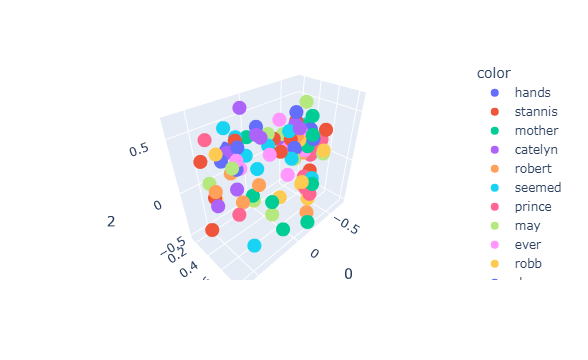

In [36]:
import plotly.express as px
fig=px.scatter_3d(X[200:300],x=0,y=1,z=2,color=y[200:300])
fig.show()